<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO03/HO03_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HO03 - Text Clustering

In [5]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

### 1. Inspecting the dataset type and shape

In [3]:
print(f"Type of newsgroups_train: {type(newsgroups_train)}")
print(f"Keys available in the dataset: {newsgroups_train.keys()}")
print(f"Number of samples: {len(newsgroups_train.data)}")
print(f"Number of target categories: {len(newsgroups_train.target_names)}")

Type of newsgroups_train: <class 'sklearn.utils._bunch.Bunch'>
Keys available in the dataset: dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])
Number of samples: 11314
Number of target categories: 20


### 2. Analyzing the distribution of categories

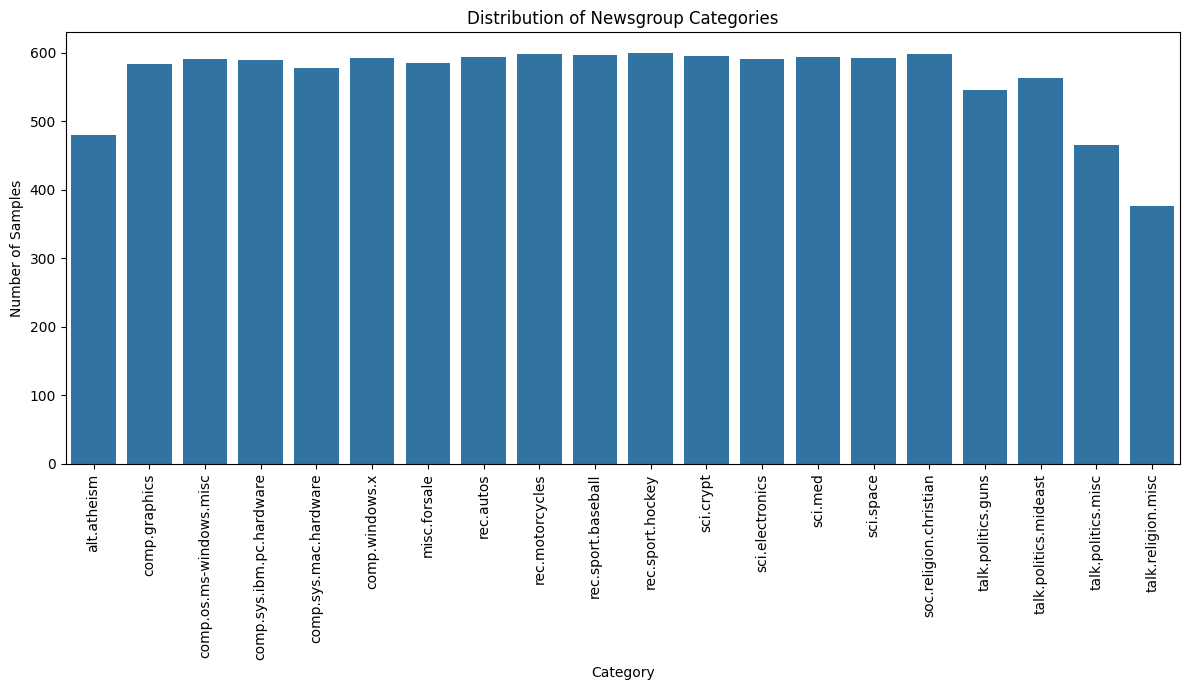

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = pd.Series(newsgroups_train.target).value_counts().sort_index()
target_names = [newsgroups_train.target_names[i] for i in target_counts.index]

plt.figure(figsize=(12, 7))
sns.barplot(x=target_names, y=target_counts.values)
plt.xticks(rotation=90)
plt.title('Distribution of Newsgroup Categories')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

### 3. Displaying a sample document and its category

In [16]:
import numpy as np

# 1. Acesso por Global Index
sample_index = 11313
print(f"--- [Global] Sample Document ({sample_index}) ---")
print(newsgroups_train.data[sample_index])
print(f"Category: {newsgroups_train.target_names[newsgroups_train.target[sample_index]]}")

print("\n" + "="*50 + "\n")

# 2. Acesso por Categoria e Index relativo
category_id = 1
relative_doc_index = 500

# Encontra os índices globais que pertencem à categoria selecionada
category_indices = np.where(newsgroups_train.target == category_id)[0]

if relative_doc_index < len(category_indices):
    global_idx = category_indices[relative_doc_index]
    print(f"--- [Category {category_id}] Document at relative index {relative_doc_index} ---")
    print(f"Category Name: {newsgroups_train.target_names[category_id]}")
    print(f"Global Index: {global_idx}")
    print("-" * 30)
    print(newsgroups_train.data[global_idx])
else:
    print(f"O índice relativo {relative_doc_index} está fora do range para esta categoria.")

--- [Global] Sample Document (11313) ---
From: gunning@cco.caltech.edu (Kevin J. Gunning)
Subject: stolen CBR900RR
Organization: California Institute of Technology, Pasadena
Lines: 12
Distribution: usa
NNTP-Posting-Host: alumni.caltech.edu
Summary: see above

Stolen from Pasadena between 4:30 and 6:30 pm on 4/15.

Blue and white Honda CBR900RR california plate KG CBR.   Serial number
JH2SC281XPM100187, engine number 2101240.

No turn signals or mirrors, lights taped over for track riders session
at Willow Springs tomorrow.  Guess I'll miss it.  :-(((

Help me find my baby!!!

kjg


Category: rec.motorcycles


--- [Category 1] Document at relative index 500 ---
Category Name: comp.graphics
Global Index: 9827
------------------------------
From: oberto@genes.icgeb.trieste.it (Jacques Oberto)
Subject: Re: HELP!!! GRASP
Organization: ICGEB
Lines: 33

CBW790S@vma.smsu.edu.Ext (Corey Webb) writes:

>In article <1993Apr19.160944.20236W@baron.edb.tih.no>
>havardn@edb.tih.no (Haavard Nesse,o92a

### 4. Listing all target category names

In [17]:
print("Target category names:")
for i, name in enumerate(newsgroups_train.target_names):
    print(f"{i}: {name}")

Target category names:
0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc


### 6. Função de Normalização de Texto (Remoção de Pontuação)

In [6]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Baixa os conjuntos de dados necessários se ainda não foram baixados
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng')

# Função auxiliar para mapear as POS tags do NLTK para as tags da WordNet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN # Padrão para substantivo se não houver tag clara

def normalize_text(text):
    """Remove pontuação, stopwords, realiza POS-tagging e lematiza uma string de texto."""
    # 1. Remover pontuação
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)

    # 2. Converter para minúsculas e tokenizar
    words = text_no_punct.lower().split()

    # 3. Remover stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # 4. POS-tagging (Parte da Fala)
    pos_tagged_words = pos_tag(filtered_words)

    # 5. Lematização
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = []
    for word, tag in pos_tagged_words:
        wntag = get_wordnet_pos(tag)
        lemmatized_words.append(lemmatizer.lemmatize(word, wntag))

    return ' '.join(lemmatized_words)

# Exemplo de uso da função
sample_text = newsgroups_train.data[0]
print(f"--- Texto original ---\n{sample_text}\n")

normalized_text_full = normalize_text(sample_text)
print(f"--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---\n{normalized_text_full}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--- Texto original ---
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----






--- Texto normalizado (sem pontuação, stopwords, POS-tagging e lematizado) ---
lerxstwamumdedu wheres thing subject car nntppostinghost rac3wamumdedu organization university maryland college park line 15 wonder anyone could enlighten car saw day 2door sp

### 7. Testando a função de normalização em outros documentos

In [19]:
# Seleciona alguns índices de documentos diferentes para testar
sample_indices = [1, 500, 1000]

for index in sample_indices:
    print(f"\n--- Documento Original ({index}) ---")
    original_text = newsgroups_train.data[index]
    print(original_text)

    print(f"\n--- Documento Normalizado ({index}) ---")
    normalized_text = normalize_text(original_text)
    print(normalized_text)
    print("="*80)


--- Documento Original (1) ---
From: guykuo@carson.u.washington.edu (Guy Kuo)
Subject: SI Clock Poll - Final Call
Summary: Final call for SI clock reports
Keywords: SI,acceleration,clock,upgrade
Article-I.D.: shelley.1qvfo9INNc3s
Organization: University of Washington
Lines: 11
NNTP-Posting-Host: carson.u.washington.edu

A fair number of brave souls who upgraded their SI clock oscillator have
shared their experiences for this poll. Please send a brief message detailing
your experiences with the procedure. Top speed attained, CPU rated speed,
add on cards and adapters, heat sinks, hour of usage per day, floppy disk
functionality with 800 and 1.4 m floppies are especially requested.

I will be summarizing in the next two days, so please add to the network
knowledge base if you have done the clock upgrade and haven't answered this
poll. Thanks.

Guy Kuo <guykuo@u.washington.edu>


--- Documento Normalizado (1) ---
guykuocarsonuwashingtonedu guy kuo subject si clock poll final call summar

### 8. Análise Estatística do Dataset Normalizado

Vamos criar uma função para contar o número de documentos e extrair o vocabulário único resultante da normalização.

In [20]:
def analyze_dataset_stats(dataset):
    """Calcula o número de documentos e a quantidade de palavras únicas após a normalização."""
    num_docs = len(dataset.data)
    unique_words = set()

    print(f"Processando {num_docs} documentos... Por favor, aguarde.")

    for doc in dataset.data:
        # Normaliza o texto
        normalized = normalize_text(doc)
        # Adiciona as palavras ao set de palavras únicas
        unique_words.update(normalized.split())

    return num_docs, len(unique_words)

# Executa a análise
total_docs, vocab_size = analyze_dataset_stats(newsgroups_train)

print(f"\n--- Estatísticas do Dataset ---")
print(f"Quantidade total de documentos: {total_docs}")
print(f"Quantidade de palavras únicas (Vocabulário): {vocab_size}")

Processando 11314 documentos... Por favor, aguarde.

--- Estatísticas do Dataset ---
Quantidade total de documentos: 11314
Quantidade de palavras únicas (Vocabulário): 130805


### 9. Construindo a representação TF-IDF manualmente

Nesta etapa, vamos transformar o texto normalizado em vetores numéricos seguindo a lógica: Matriz de Contagem (TF) e Matriz IDF.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
from scipy.sparse import csr_matrix

# 1. Preparar os dados normalizados (processando novamente para garantir consistência)
print("Normalizando documentos para a matriz...")
corpus_normalized = [normalize_text(doc) for doc in newsgroups_train.data]

# 2. Gerar a Matriz de Contagem (Counting Vectors)
# Limitamos o vocabulário para evitar estouro de memória se necessário,
# mas aqui usaremos o total identificado anteriormente.
vectorizer = CountVectorizer()
counting_matrix = vectorizer.fit_transform(corpus_normalized)

print(f"Formato da Matriz de Contagem: {counting_matrix.shape}")

Normalizando documentos para a matriz...
Formato da Matriz de Contagem: (11314, 130757)


In [8]:
# 3. Calcular o IDF
# df (document frequency) é o número de documentos que contêm o termo
df = np.diff(counting_matrix.tocsc().indptr)

# Fórmula do IDF: log(N / df) + 1 (usando a suavização padrão do sklearn)
# N é o número total de documentos
N = counting_matrix.shape[0]
idf = np.log((1 + N) / (1 + df)) + 1

print(f"Vetor IDF gerado com {len(idf)} termos.")

Vetor IDF gerado com 130757 termos.


In [9]:
# 4. Gerar a Matriz TF-IDF
# A multiplicação é elemento a elemento entre a contagem e o peso IDF de cada coluna
from sklearn.preprocessing import normalize

# Criamos uma matriz diagonal de pesos IDF para multiplicar
idf_diag = csr_matrix((idf, (np.arange(len(idf)), np.arange(len(idf)))), shape=(len(idf), len(idf)))
tfidf_matrix_manual = counting_matrix @ idf_diag

# Normalização L2 (comum no TF-IDF para que documentos longos não tenham pesos desproporcionais)
tfidf_matrix_manual = normalize(tfidf_matrix_manual, norm='l2', axis=1)

print("Matriz TF-IDF final gerada com sucesso.")
print(f"Exemplo de valores na primeira linha (primeiros 5 termos não-zero):")
first_row = tfidf_matrix_manual[0].tocoo()
for r, c, v in list(zip(first_row.row, first_row.col, first_row.data))[:5]:
    print(f"  Termo: {vectorizer.get_feature_names_out()[c]} | Peso: {v:.4f}")

Matriz TF-IDF final gerada com sucesso.
Exemplo de valores na primeira linha (primeiros 5 termos não-zero):
  Termo: lerxst | Peso: 0.2152
  Termo: neighborhood | Peso: 0.1554
  Termo: bring | Peso: 0.0965
  Termo: il | Peso: 0.1298
  Termo: thanks | Peso: 0.0675


### NOTA:
Muito provavelmente o termo **lerxst** é referente ao destinatário ou rementente do email. O fato dele ter um peso um pouco mais alto do que palavras como "**thanks**" ou "**bring**" indica que a normalização TF-IDF funcionou certinho. Mas talvez essa palavra devesse ser tratada como um ruido

### 10. Representação Word2Vec

Enquanto o TF-IDF foca na importância estatística das palavras, o Word2Vec cria embeddings densos que capturam relações semânticas entre elas. Vamos usar a biblioteca `gensim` para esta tarefa.

In [24]:
!pip install --upgrade gensim

In [25]:
from gensim.models import Word2Vec
import logging

# 1. Preparar os dados (Word2Vec espera uma lista de listas de tokens)
print("Preparando tokens para o Word2Vec...")
tokenized_corpus = [doc.split() for doc in corpus_normalized]

# 2. Treinar o modelo Word2Vec
print("Treinando o modelo Word2Vec (isso pode levar alguns instantes)...")
w2v_model = Word2Vec(sentences=tokenized_corpus,
                     vector_size=100,
                     window=5,
                     min_count=2,
                     workers=4)

print("Modelo Word2Vec treinado com sucesso!")

# 3. Demonstrando o Word2Vec: Encontrando palavras similares
word_to_test = "space"
if word_to_test in w2v_model.wv:
    print(f"\nPalavras mais similares a '{word_to_test}':")
    similar_words = w2v_model.wv.most_similar(word_to_test, topn=5)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")

print(f"\nFormato do vetor da palavra '{word_to_test}': {w2v_model.wv[word_to_test].shape}")

Preparando tokens para o Word2Vec...
Treinando o modelo Word2Vec (isso pode levar alguns instantes)...
Modelo Word2Vec treinado com sucesso!

Palavras mais similares a 'space':
  shuttle: 0.8543
  nasa: 0.8353
  redesign: 0.8079
  launch: 0.7865
  mission: 0.7741

Formato do vetor da palavra 'space': (100,)


In [26]:
# 3. Demonstrando o Word2Vec: Encontrando palavras similares
word_to_test = "image"
if word_to_test in w2v_model.wv:
    print(f"Palavras mais similares a '{word_to_test}':")
    similar_words = w2v_model.wv.most_similar(word_to_test, topn=5)
    for word, score in similar_words:
        print(f"  {word}: {score:.4f}")

# Exemplo de vetor para uma palavra
print(f"\nFormato do vetor da palavra '{word_to_test}': {w2v_model.wv[word_to_test].shape}")

Palavras mais similares a 'image':
  jpeg: 0.8810
  gif: 0.8804
  map: 0.8766
  render: 0.8605
  display: 0.8596

Formato do vetor da palavra 'image': (100,)


### 11. Função para Plotar pontos em um mapa

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
import sklearn.mixture as GMM
import time
import hdbscan
%matplotlib inline
sns.set_context('poster')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}

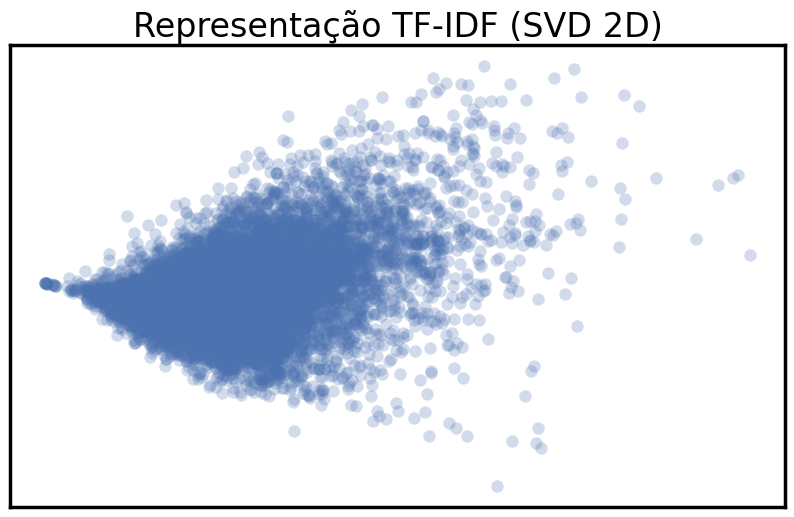

In [11]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Usando a representação que já calculamos anteriormente
# Certifique-se de que a célula onde 'tfidf_matrix_manual' é definida foi executada
if 'tfidf_matrix_manual' in globals():
    svd = TruncatedSVD(n_components=2, random_state=42)
    data_2d = svd.fit_transform(tfidf_matrix_manual)

    plt.figure(figsize=(10, 6))
    plt.scatter(data_2d.T[0], data_2d.T[1], c='b', **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Representação TF-IDF (SVD 2D)')
    plt.show()
else:
    print("Erro: A variável 'tfidf_matrix_manual' não foi encontrada. Por favor, execute a célula do passo 9.4 primeiro.")

In [12]:
def plot_clusters(data, algorithm, args, kwds):
    start_time = time.time()
    labels = algorithm(*args, **kwds).fit_predict(data)
    end_time = time.time()
    palette = sns.color_palette('deep', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters by {}'.format(str(algorithm.__name__)), fontsize=18)
    plt.text(-0.5, 0.6, 'Running Time {:.2f} s'.format(end_time - start_time), fontsize=14)

### 12. Clusterização com K-Means (TF-IDF vs Word2Vec)

Vamos comparar como os documentos se agrupam usando as duas representações vetoriais diferentes.